# Baseline Model — Linear Regression
**Notebook 03 — IDX Exchange Data Science Internship 2026**

This notebook trains a Linear Regression model as the baseline for comparison 
against more advanced models in subsequent notebooks. A random seed is set for 
reproducibility.

**Input:** `train_cleaned.csv` and `test_cleaned.csv` from Notebook 02  
**Output:** Baseline R², RMSE, MAE, MAPE, and MdAPE metrics

In [29]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path
from matplotlib.ticker import StrMethodFormatter
import random
import numpy as np
np.random.seed(42)

In [7]:
# loading in test/train split data
filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
train_df = pd.read_csv(filepath + r"\train_cleaned.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_cleaned.csv", low_memory=False)

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows:  {len(test_df):,}")
print(f"Columns: {train_df.shape[1]}")

Training rows: 315,683
Testing rows:  12,634
Columns: 57


## 1. Feature Selection & Leakage Prevention

Before training, leakage variables are removed as these are columns that would 
not be available at prediction time or that directly encode the target variable:

| Column | Reason for Removal |
|---|---|
| `CloseDate` | Only known after sale closes |
| `ListPrice` | Too directly correlated with ClosePrice |
| `OriginalListPrice` | Same issue as ListPrice |
| `ListingKey` / `ListingKeyNumeric` | Unique identifiers, no predictive value |
| `DaysOnMarket` | Only known after sale closes |
| `HighSchoolDistrict` | String column — encoded version used in Notebook 04 |

In [11]:
# chosing target variable, creating x and y

target = "ClosePrice"
x_train = train_df.drop(columns=["ClosePrice"]) # we want to train on ClosePrice so we remove it here
x_test = test_df.drop(columns=["ClosePrice"])

y_train = train_df['ClosePrice']
y_test = test_df['ClosePrice']

drop_cols = [                                  # these columns are dropped because they would either be known after closing the house or introduce leakages
    "CloseDate",                
    "ListPrice",             
    "OriginalListPrice",
    "ListingKey",
    "ListingKeyNumeric",
    "DaysOnMarket",
    "HighSchoolDistrict"
]

x_train = x_train.drop(columns=drop_cols, errors="ignore") # dropping the rest of the leakage or unnecessary columns
x_test = x_test.drop(columns=drop_cols, errors="ignore")


## 2. Linear Regression

A Linear Regression model is trained as the baseline. Linear regression assumes 
a linear relationship between each feature and the target variable (ClosePrice). 
While this is a simplification of the real estate market, it provides a useful 
performance floor that all subsequent models must meaningfully improve upon.

In [14]:
# training the linear regression model

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

## 3. Evaluation Metrics

The following metrics are used to evaluate model performance throughout this project:

- **R²** — proportion of variance in ClosePrice explained by the model (higher is better, max 1.0)
- **RMSE** — root mean squared error in dollars, penalizes large errors more heavily
- **MAE** — mean absolute error in dollars, average prediction error
- **MAPE** — mean absolute percentage error, average percentage prediction error
- **MdAPE** — median absolute percentage error, typical percentage error robust to outliers. This is the primary metric we use for this project. 

MdAPE is preferred over MAPE for real estate because a small number of very 
wrong predictions on extreme-priced properties would pull the mean up significantly. 
The median is unaffected by these outliers and better represents typical model performance.

In [ ]:
#metric function
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape, "MdAPE": mdape}

## 4. Baseline Results

The Linear Regression baseline establishes the performance floor for this project. 
All subsequent models (Decision Tree, Random Forest, LightGBM, XGBoost) are 
expected to meaningfully improve on these metrics.

A predicted vs. actual scatter plot is included, points close to the red diagonal 
line represent accurate predictions. The spread of points away from the line 
indicates where the model struggles.

In [ ]:
y_pred = lr.predict(x_test)
results = evaluate_model(y_test, y_pred, label="Linear Regression Baseline")


Linear Regression Baseline
R²:    0.4787
RMSE:  $653,574
MAE:   $436,431
MAPE:  43.73%
MdAPE: 30.42%


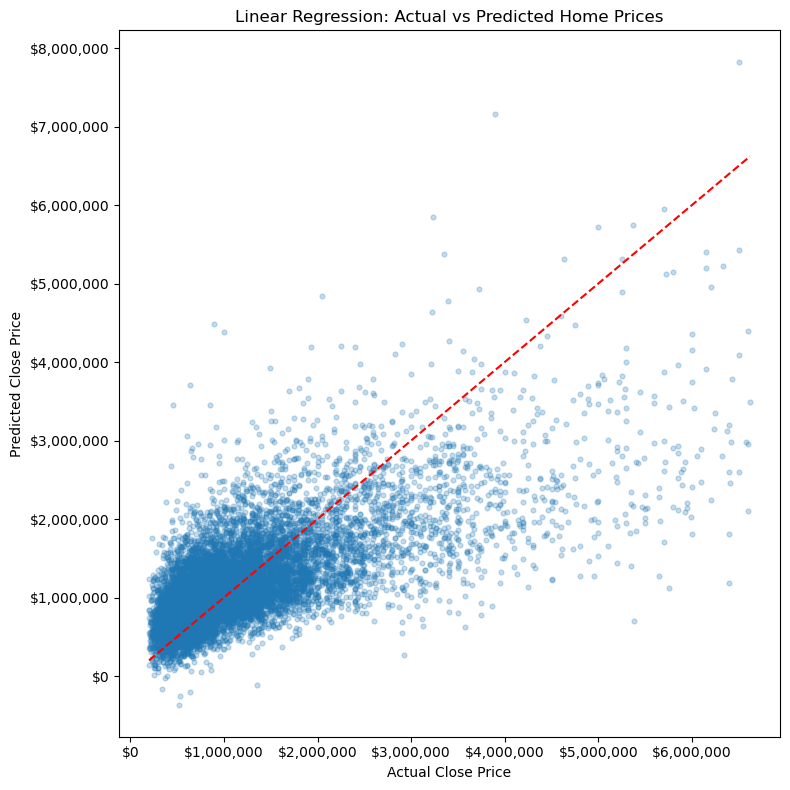

In [31]:
# predicted vs actual plot
plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.25, s=12)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Linear Regression: Actual vs Predicted Home Prices")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()